# ProtST as a decision model: zero-shot, then a head

> Ask typed questions about proteins with ProtST: zero-shot from its joint space first, then a head trained on its frozen towers, and a rule for when to hand a question back instead of answering it.

- skip_exec: true
- skip_showdoc: true

[ProtST](https://arxiv.org/abs/2301.12040) pairs a protein language model (ESM-1b) with a biomedical text encoder (PubMedBERT), trained so that a protein and a description of it lie close together in one space. That's enough to answer questions about a protein without any training. Embed the protein, embed each possible answer's text, and pick the closest. sysone turns this into a Laya-style decision model. You pass a protein sequence and typed questions (choices, nouls), and get calibrated answers back in the Jev schema, with an *act or escalate* flag once a head has been trained.

This tutorial asks three questions about each protein:

- **location**, a `choice` of ten compartments: *Where in the cell is this protein found?* Localization is a standard ProtST benchmark (DeepLoc's ten classes).
- **membrane**, a `noul`: *The protein is bound to a membrane.* True or false, for the proteins that DeepLoc also labels as membrane-bound or soluble.
- **shortlist**, a `choice` of four: *Which of these compartments is the protein found in?* For a third of the proteins, the right compartment is not on the list. A decision model should notice that and escalate instead of answering. Laya's act head is trained for exactly this, and the last part of the notebook compares it with a simpler rule.

First, ProtST answers all three zero-shot, with a few ways of phrasing the options. Then a head is trained on ProtST's frozen towers, on 1,200 proteins, and the two are compared on 600 held-out proteins, first on their answers and then on when they choose to act. The [protein](../22_protein.ipynb) notebook explains the pieces: how sysone loads ProtST without running the repo's code, the embedders, and the stream encoder. This one uses them the way a user would.

::: {.callout-note title="Running this notebook"}
The test suite skips this notebook (`skip_exec`). It downloads [MilaDeepGraph/ProtST-ESM1b](https://huggingface.co/MilaDeepGraph/ProtST-ESM1b), whose `pytorch_model.bin` is 1.53 GB. sysone reads the tensors with `torch.load(weights_only=True)` and never runs the repo's `modeling_protst.py`. The notebook also downloads the ESM-1b and PubMedBERT tokenizers and three small datasets, [ProtST-SubcellularLocalization](https://huggingface.co/datasets/Jiqing/ProtST-SubcellularLocalization), [ProtST-BinaryLocalization](https://huggingface.co/datasets/Jiqing/ProtST-BinaryLocalization) and [subloc_template](https://huggingface.co/datasets/Jiqing/subloc_template) (about 14 MB together). The model card and the dataset cards state no licence, so check ProtST's own repository before using them beyond research.

Once the files are downloaded, the whole run takes about 13 minutes on an M3 Pro (MPS, float32), and its resident memory peaked at 5.2 GB. Free memory on the 18 GB machine never fell below 26%. The outputs below come from a run on 2026-09-27. The float32 towers take 3 GB, and ProtST is loaded once and shared by everything below. Proteins go through ESM in batches of 8. The notebook keeps its feature cache and its export in `protein-decisions/`, next to the notebook. It needs the `plots` extra (`pip install "sysone[plots]"`).
:::

```{mermaid}
flowchart LR
    R["a record: a protein sequence,<br/>typed questions, the gold"] --> Z["zero-shot: ProtST's two towers,<br/>scale × cosine per option"]
    R --> S["the protein application:<br/>PubMedBERT reads the question,<br/>ESM reads the protein"]
    S --> C["cached vectors<br/>(frozen towers)"]
    C --> H["pair head + act head,<br/>trained on 1,200 proteins"]
    Z --> A["answers: calibrated<br/>probabilities"]
    H --> A2["answers, and act<br/>or escalate"]
```

In [ ]:
import gc, io, json, logging, resource, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
from matplotlib.patches import Rectangle
from matplotlib_inline.backend_inline import set_matplotlib_formats
from IPython.display import Image as DisplayImage, display
import datasets, huggingface_hub, transformers
from huggingface_hub import hf_hub_download
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from sysone.core import Question, lookup_threshold
from sysone.data import TypedDecisions
from sysone.losses import answer_metrics, coverage_curve
from sysone.template import show_row
from sysone.zeroshot import CachedEmbedder
from sysone.inference import Decider
from sysone.protein import ProteinEmbedder, clean_sequence, decision_learner, load_protst, zero_shot

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
datasets.logging.set_verbosity_error(); huggingface_hub.utils.logging.set_verbosity_error()
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
work = Path("protein-decisions")          # the feature cache and the export
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


Two small helpers. `quiet` takes the Trainer's printer off the learner, so it doesn't print a line of logs every few steps (`learn.recorder` keeps the numbers). `memory` reports what the process holds: its peak resident memory, and on MPS what the GPU driver has allocated. The notebook calls it after each heavy step.

In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs (`learn.recorder` still has them)"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def memory() -> str:
    "The process's peak resident memory, and what the MPS driver holds"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (2**30 if sys.platform == "darwin" else 2**20)   # bytes on macOS, KB on Linux
    mps = f" · MPS driver {torch.mps.driver_allocated_memory() / 2**30:.1f} GB" if torch.backends.mps.is_available() else ""
    return f"peak RSS {rss:.1f} GB{mps}"

## ProtST, loaded once

`load_protst` builds transformers' own `EsmModel` and `BertModel` from the checkpoint's config and fills them with its tensors. The two projection heads map each tower's pooled vector into the 512-wide joint space. Everything below shares this one copy: the zero-shot embedders, the learner's stream encoder and its `Decider`.

In [ ]:
t0 = time.time()
protst = load_protst(device=device)
print(protst)
print(f"loaded in {time.time() - t0:.0f} s · {memory()}")

ProtST(MilaDeepGraph/ProtST-ESM1b · protein: ESM 33 × 1280 · text: BERT 12 × 768 · joint space 512 · scale 14.2 · 762.9M params · torch.float32 on mps:0)
loaded in 1 s · peak RSS 4.8 GB · MPS driver 3.0 GB


## The data

The localization dataset gives each protein one of ten compartments, from DeepLoc, and keeps DeepLoc's train, validation and test splits. The template file holds the ten label texts that ProtST's zero-shot example uses, and a longer description of each:

In [ ]:
REPO_LOC, REPO_BIN, REPO_TPL = "Jiqing/ProtST-SubcellularLocalization", "Jiqing/ProtST-BinaryLocalization", "Jiqing/subloc_template"
loc = {s: pd.read_parquet(hf_hub_download(REPO_LOC, f"data/{s}-00000-of-00001.parquet", repo_type="dataset")) for s in ("train", "validation", "test")}
binary = pd.concat([pd.read_csv(hf_hub_download(REPO_BIN, f"binary-localization_{s}.csv", repo_type="dataset")) for s in ("train", "validation", "test")],
                   ignore_index=True)
template = pd.read_csv(hf_hub_download(REPO_TPL, "subloc_template.csv", repo_type="dataset"))
print({s: len(d) for s, d in loc.items()}, "proteins ·", len(binary), "with a membrane label")
with pd.option_context("display.max_colwidth", 120): display(template[["name", "description"]])

{'train': 8420, 'validation': 2811, 'test': 2773} proteins · 8662 with a membrane label


,name,description
0,SUBCELLULAR LOCATION: Cell membrane.,SUBCELLULAR LOCATION: Apical; apicolateral; basal; basolateral; lateral; cell membrane; cell projection.
1,SUBCELLULAR LOCATION: Cytoplasm.,SUBCELLULAR LOCATION: Cytoplasm (cytosol and cytoskeleton).
2,SUBCELLULAR LOCATION: Endoplasmic reticulum (ER).,SUBCELLULAR LOCATION: ER membrane and lumen; microsome; rough ER; smooth ER; Sarcoplasmic reticulum.
3,SUBCELLULAR LOCATION: Golgi apparatus.,SUBCELLULAR LOCATION: Golgi apparatus membrane and lumen.
4,SUBCELLULAR LOCATION: Lysosome/Vacuole.,SUBCELLULAR LOCATION: Contractile; lytic and protein storage vacuole; vacuole lumen and membrane; lysosome lumen and...
5,SUBCELLULAR LOCATION: Mitochondrion.,SUBCELLULAR LOCATION: Envelope; inner and outer membrane; matrix; intermembrane space.
6,SUBCELLULAR LOCATION: Nucleus.,SUBCELLULAR LOCATION: Envelope; inner and outer membrane; matrix; lamina; chromosome; nucleus speckle.
7,SUBCELLULAR LOCATION: Peroxisome.,SUBCELLULAR LOCATION: Peroxisome matrix and membrane.
8,SUBCELLULAR LOCATION: Plastid.,SUBCELLULAR LOCATION: Plastid membrane; stroma and thylakoid.
9,SUBCELLULAR LOCATION: Extracellular.,SUBCELLULAR LOCATION: Extracellular.


The membrane labels are 0 and 1, and the dataset card doesn't say which is which. Every protein in the binary dataset is also in the localization dataset, so their compartments settle it:

In [ ]:
seq_loc = {clean_sequence(s): y for d in loc.values() for s, y in zip(d.prot_seq, d.localization)}
b = binary.assign(compartment=[template.name[seq_loc[clean_sequence(s)]].removeprefix("SUBCELLULAR LOCATION: ") for s in binary.prot_seq])
pd.crosstab(b.compartment, b.localization).rename(columns={0: "label 0", 1: "label 1"})

localization,label 0,label 1
compartment,,
Cell membrane.,1340,0
Cytoplasm.,0,2542
Endoplasmic reticulum (ER).,720,61
Extracellular.,0,1973
Golgi apparatus.,301,2
Lysosome/Vacuole.,243,4
Mitochondrion.,516,233
Nucleus.,122,134
Peroxisome.,48,6


Every cell-membrane protein is labelled 0 and every cytoplasmic and extracellular one is labelled 1, so **0 means membrane-bound** and 1 soluble. Most of the organelles' proteins are on the membrane-bound side, and the nucleus splits about evenly (122 to 134). The records below store the noul's gold as `True` for label 0. Had the labels been read the other way round, every membrane result below would have been inverted without any error to show for it.

Each record holds the protein's sequence and the three questions. The location question's options carry ProtST's label texts as descriptions. Where DeepLoc has a membrane label the record asks the membrane noul, and every record gets a shortlist of four compartments. A third of the shortlists leave the true compartment out, and their gold is `{"answerable": False}`. The splits follow the dataset's: 1,200 proteins from its train split to train on, 250 and 300 from its validation split for validation and calibration, and 600 from its test split to score.

In [ ]:
KEYS = ["cell membrane", "cytoplasm", "endoplasmic reticulum", "Golgi apparatus", "lysosome or vacuole", "mitochondrion",
        "nucleus", "peroxisome", "plastid", "extracellular space"]
NAMES = dict(zip(KEYS, template.name.str.strip()))     # "SUBCELLULAR LOCATION: Nucleus.": ProtST's label texts
DESCRIPTIONS = dict(zip(KEYS, template.description.str.strip()))
SHORT = dict(zip(KEYS, ["membrane", "cytoplasm", "ER", "Golgi", "lysosome", "mitochondrion", "nucleus", "peroxisome", "plastid", "extracellular"]))
MEMBRANE_GOLD = {clean_sequence(s): y == 0 for s, y in zip(binary.prot_seq, binary.localization)}
LOCATION = {"type": "choice", "instructions": "Where in the cell is this protein found?", "criteria": NAMES}
MEMBRANE = {"type": "noul", "instructions": "The protein is bound to a membrane.",
            "criteria": {"false": "a soluble protein", "true": "a membrane protein"}}

def make_records(df, n, seed, split):
    "n proteins of a split as records: the location, the membrane noul where known, and a shortlist that leaves the answer out a third of the time"
    rng, rows = np.random.default_rng(seed), df.sample(n, random_state=seed)
    out = []
    for i, (s, y) in enumerate(zip(rows.prot_seq, rows.localization)):
        seq, gold = clean_sequence(s), KEYS[y]
        qs, g = {"location": LOCATION}, {"location": gold}
        if seq in MEMBRANE_GOLD: qs["membrane"], g["membrane"] = MEMBRANE, MEMBRANE_GOLD[seq]
        answerable = rng.random() >= 1 / 3
        picks = list(rng.choice([k for k in KEYS if k != gold], 3 if answerable else 4, replace=False)) + ([gold] if answerable else [])
        qs["shortlist"] = {"type": "choice", "instructions": "Which of these compartments is the protein found in?",
                           "criteria": {k: NAMES[k] for k in sorted(picks, key=KEYS.index)}}
        g["shortlist"] = gold if answerable else {"answerable": False}
        out.append({"id": f"{split}-{i}", "state": {"sequence": seq}, "questions": qs, "gold": g})
    return out

valid_calib = make_records(loc["validation"], 550, 1, "validation")
train_recs, valid_recs, calib_recs = make_records(loc["train"], 1200, 0, "train"), valid_calib[:250], valid_calib[250:]
test_recs = make_records(loc["test"], 600, 2, "test")
shown = test_recs[0] | {"state": {"sequence": test_recs[0]["state"]["sequence"][:50] + "…"}}
print(json.dumps(shown, indent=1)[:1600])

{
 "id": "test-0",
 "state": {
  "sequence": "MNNARTNAKRRRLSSKQGGLSISEGKESNIPSVVEESKDNLEQASADDRL\u2026"
 },
 "questions": {
  "location": {
   "type": "choice",
   "instructions": "Where in the cell is this protein found?",
   "criteria": {
    "cell membrane": "SUBCELLULAR LOCATION: Cell membrane.",
    "cytoplasm": "SUBCELLULAR LOCATION: Cytoplasm.",
    "endoplasmic reticulum": "SUBCELLULAR LOCATION: Endoplasmic reticulum (ER).",
    "Golgi apparatus": "SUBCELLULAR LOCATION: Golgi apparatus.",
    "lysosome or vacuole": "SUBCELLULAR LOCATION: Lysosome/Vacuole.",
    "mitochondrion": "SUBCELLULAR LOCATION: Mitochondrion.",
    "nucleus": "SUBCELLULAR LOCATION: Nucleus.",
    "peroxisome": "SUBCELLULAR LOCATION: Peroxisome.",
    "plastid": "SUBCELLULAR LOCATION: Plastid.",
    "extracellular space": "SUBCELLULAR LOCATION: Extracellular."
   }
  },
  "shortlist": {
   "type": "choice",
   "instructions": "Which of these compartments is the protein found in?",
   "criteria": {
    "cel

In [ ]:
def split_summary(recs):
    "How many proteins, membrane nouls and unanswerable shortlists a split holds, and its commonest compartment's share"
    gold = pd.Series([r["gold"]["location"] for r in recs])
    return {"proteins": len(recs), "membrane nouls": sum("membrane" in r["questions"] for r in recs),
            "unanswerable shortlists": sum(isinstance(r["gold"]["shortlist"], dict) for r in recs),
            "median length": int(np.median([len(r["state"]["sequence"]) for r in recs])),
            "commonest": f"{gold.value_counts().index[0]} ({gold.value_counts(normalize=True).iloc[0]:.0%})"}

pd.DataFrame({n: split_summary(r) for n, r in [("train", train_recs), ("valid", valid_recs), ("calib", calib_recs), ("test", test_recs)]}).T

,proteins,membrane nouls,unanswerable shortlists,median length,commonest
train,1200,745,386,420,nucleus (29%)
valid,250,140,80,401,nucleus (32%)
calib,300,188,103,419,nucleus (25%)
test,600,360,198,439,nucleus (30%)


The nucleus is the commonest compartment in every split, a quarter to a third of the proteins, so always answering *nucleus* is the bar to beat on the location question: 0.30 on the test proteins. About three proteins in five carry the membrane noul, and a third of the shortlists are unanswerable by construction. The median protein has about 420 residues, and 66 of the 600 test proteins have exactly 1,000. The dataset cut longer proteins to 1,000 residues before release (DeepLoc, where they come from, keeps the first and last 500), so none needs cropping to fit ESM-1b's 1,022.

The rare compartments are rare indeed: the 1,200 training proteins include 17 peroxisomal, 24 lysosomal and 27 Golgi proteins, against 346 nuclear ones.

### What a protein looks like

A protein is a string of amino acids, and a few features of it can be read by eye. The plots below show the Kyte–Doolittle hydropathy of each protein, the hydrophobicity of its residues averaged over a window of 19. A stretch that stays above 1.6 over the window is long and hydrophobic enough to cross a membrane as a helix. A short hydrophobic stretch at the very start is typical of a signal peptide, which sends a protein into the secretory pathway. These are the kind of features ESM has learnt to read, among many others that no scale shows.

In [ ]:
#| code-fold: true
#| code-summary: plotting helpers
BLUE, LIGHT, TRACK, CARD, INK, GRAY, RED = "#3b3ff5", "#9a9df7", "#d4d4d4", "#f2f2f2", "#111111", "#6b6b6b", "#d62728"
KD = dict(A=1.8, R=-4.5, N=-3.5, D=-3.5, C=2.5, Q=-3.5, E=-3.5, G=-0.4, H=-3.2, I=4.5, L=3.8, K=-3.9, M=1.9, F=2.8,
          P=-1.6, S=-0.8, T=-0.7, W=-0.9, Y=-1.3, V=4.2)

def hydropathy(seq, window=19):
    "Kyte–Doolittle hydropathy, averaged over a sliding window of residues"
    v = np.array([KD.get(a, 0.0) for a in seq])
    return np.convolve(v, np.ones(window) / window, mode="valid") if len(v) >= window else v

def show_figure(fig, dpi=90):
    "Display a figure as PNG and close it"
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=dpi); plt.close(fig)
    display(DisplayImage(buf.getvalue(), format="png"))

def _line(ax, x, y, parts, size):
    "Pieces of text in their own weight and colour on one line, its top left corner at (x, y) in axes fraction"
    box = HPacker(children=[TextArea(s, textprops=dict(size=size, **kw)) for s, kw in parts], sep=size * 0.35, pad=0, align="baseline")
    ax.add_artist(AnchoredOffsetbox("upper left", child=box, bbox_to_anchor=(x, y), bbox_transform=ax.transAxes,
                                    frameon=False, pad=0, borderpad=0))

def _profile(ax, seq):
    "A protein's hydropathy profile, the stretches above 1.6 filled"
    h = hydropathy(seq); x = np.arange(len(h)) + 9
    ax.plot(x, h, color=GRAY, lw=0.8); ax.axhline(1.6, color=RED, lw=0.6, ls=":")
    ax.fill_between(x, 1.6, h, where=h > 1.6, color=RED, alpha=0.5, lw=0)
    ax.set_xlim(0, max(len(seq), 20)); ax.set_ylim(-3.5, 3.5); ax.set_yticks([]); ax.tick_params(labelsize=7)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)

def _card(sf, seq, gold, probs, top, note=""):
    "One card: the gold compartment's probability and rank, the protein's hydropathy, and the most likely compartments as bars"
    sf.set_facecolor(CARD)
    order = sorted(probs, key=probs.get, reverse=True)
    head = sf.add_axes([0.03, 0.83, 0.94, 0.13]); head.axis("off")
    rank = order.index(gold) + 1 if gold in probs else None
    _line(head, 0, 1, [(f"{gold} ({probs.get(gold, 0):.1%})", dict(weight="bold", color=INK)),
                       (f"ranked {rank} of {len(order)}" if rank else "not an option", dict(color=GRAY)), (note, dict(color=GRAY))], 11)
    ax = sf.add_axes([0.04, 0.16, 0.34, 0.6]); _profile(ax, seq)
    ax.set_xlabel(f"{len(seq)} residues", fontsize=8, color=GRAY)
    bars = sf.add_axes([0.43, 0.06, 0.54, 0.72]); bars.axis("off"); bars.set_xlim(0, 1); bars.set_ylim(0, 1)
    for i, lab in enumerate(order[:top]):
        y, ok = 1 - i / top, lab == gold
        bars.add_patch(Rectangle((0, y - 0.08), 1, 0.055, color=TRACK, lw=0))
        bars.add_patch(Rectangle((0, y - 0.08), max(probs[lab], 0.004), 0.055, color=BLUE if i == 0 else LIGHT, lw=0))
        _line(bars, 0, y - 0.1, [("✓" if ok else "✕", dict(color=INK if ok else GRAY)),
                                 (f"{lab} {probs[lab]:.0%}", dict(weight="bold", color=INK if ok else GRAY))], 10.5)

def show_cards(cards, ncols=2, top=4):
    "Prediction cards in a grid, each a dict of the sequence, the gold compartment and every compartment's probability"
    nrows = -(-len(cards) // ncols)
    fig = plt.figure(figsize=(6.4 * ncols, 2.7 * nrows))
    sfs = np.atleast_1d(fig.subfigures(nrows, ncols, wspace=0.02, hspace=0.05)).ravel()
    for sf, c in zip(sfs, cards): _card(sf, c["seq"], c["gold"], c["probs"], top, c.get("note", ""))
    for sf in sfs[len(cards):]: sf.set_facecolor("white")
    show_figure(fig)

def show_profiles(recs, ncols=3):
    "Hydropathy profiles of a few proteins, each titled with its compartment and membrane label"
    nrows = -(-len(recs) // ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 1.7 * nrows), squeeze=False)
    for ax, r in zip(axs.ravel(), recs):
        _profile(ax, r["state"]["sequence"])
        m = r["gold"].get("membrane"); tag = "" if m is None else " · membrane-bound" if m else " · soluble"
        ax.set_title(f"{r['gold']['location']}{tag} · {len(r['state']['sequence'])} aa", fontsize=9, loc="left")
    for ax in axs.ravel()[len(recs):]: ax.axis("off")
    fig.tight_layout(); show_figure(fig)

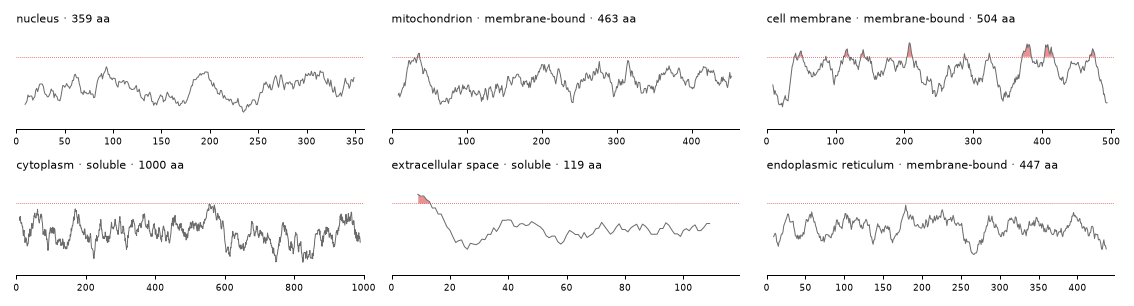

In [ ]:
picks = {}
for r in test_recs:
    if r["gold"]["location"] in ("cell membrane", "extracellular space", "nucleus", "mitochondrion", "endoplasmic reticulum", "cytoplasm"):
        picks.setdefault(r["gold"]["location"], r)
card_recs = list(picks.values())
show_profiles(card_recs)

The cell-membrane protein rises above 1.6 again and again along its length (up to 2.6), where its transmembrane helices would be. The secreted protein is hydrophobic only at its very start (*MKVAVVLIVVLVVMMIG…*), where its signal peptide sits. Hydropathy is only a hint, though. The ER protein is labelled membrane-bound but never reaches 1.6, and the mitochondrial one crosses it only briefly, near residue 35. A model has to read more than hydrophobicity to place these.

## Zero-shot

`zero_shot(protst, prompt)` is a `SimilarityDecider` over ProtST's two towers. It embeds the protein with ESM, then each option's text with PubMedBERT, and an option's logit is ProtST's logit scale (14.2) times the cosine between the two. The prompt decides the option texts. `{text}` is an option's description (for the location question, ProtST's label text) and `{key}` is its name.

Every prompt embeds the same proteins, so they share one protein embedder behind a `CachedEmbedder`. Each protein goes through ESM once, and each prompt only embeds its ten option texts. The calibration and test proteins are embedded first, in length order, so that each batch of 8 is mostly residues rather than padding.

In [ ]:
proteins = CachedEmbedder(ProteinEmbedder(protst, max_len=1024, batch_size=8))
t0 = time.time()
seqs = sorted({r["state"]["sequence"] for r in calib_recs + test_recs}, key=len)
for i in range(0, len(seqs), 150): proteins(seqs[i:i + 150])
print(f"{len(seqs)} proteins embedded in {time.time() - t0:.0f} s ({(time.time() - t0) / len(seqs) * 1000:.0f} ms each) · {memory()}")

900 proteins embedded in 203 s (226 ms each) · peak RSS 4.8 GB · MPS driver 3.0 GB


The helpers below take a decider and records, and score one question at a time. `only` keeps the questions asked, optionally with other option texts. `answer_all` answers every record, and `scores` gives the accuracy, the macro-F1 (the mean over the classes of each class's F1, which a model can't raise by favouring the common classes), the Brier score and the expected calibration error (ECE) for each question.

In [ ]:
def only(recs, *qids, criteria=None):
    "The records with only the questions `qids` and their gold; `criteria` replaces a question's option texts"
    out = []
    for r in recs:
        qs = {q: r["questions"][q] | ({"criteria": criteria[q]} if criteria and q in criteria else {}) for q in qids if q in r["questions"]}
        if qs: out.append(r | {"questions": qs, "gold": {q: r["gold"][q] for q in qs}})
    return out

def answer_all(model, recs):
    "Every record's answers, one `predict` per record"
    return [model.predict(r["state"], r["questions"]) for r in recs]

def scores(recs, answers, qids=("location", "membrane", "shortlist")):
    "Accuracy, macro-F1, Brier and ECE per question, over the rows whose gold is among the options"
    out = {}
    for qid in qids:
        trip = [({qid: r["questions"][qid]}, a, {qid: r["gold"][qid]}) for r, a in zip(recs, answers) if qid in r["questions"] and qid in a]
        m = answer_metrics(trip) if trip else None
        if m and m["n"]: out[qid] = {k: round(m[k], 3) for k in ("accuracy", "macro_f1", "brier", "ece")} | {"n": m["n"]}
    return pd.DataFrame(out).T.astype({"n": int})

Four ways to write the location question's options. ProtST's label texts are the port's own zero-shot choice (*SUBCELLULAR LOCATION: Nucleus.*). The compartment names alone and a plain sentence test how much that wording matters. The descriptions are the template's longer texts (*SUBCELLULAR LOCATION: Envelope; inner and outer membrane; matrix; …*). Each decider is calibrated on the 300 calibration proteins, which fits one temperature per question type and option count (and, with `act_accuracy=0.9`, the thresholds used in [the last part](#acting-or-escalating)), then scored on the 600 test proteins:

In [ ]:
PROMPTS = {"ProtST's label texts": ("{text}", None), "compartment names": ("{key}", None),
           "a sentence": ("A protein located in the {key}.", None), "the descriptions": ("{text}", {"location": DESCRIPTIONS})}
zs_scores, zs_answers, deciders = {}, {}, {}
for name, (prompt, crit) in PROMPTS.items():
    zs = zero_shot(protst, prompt=prompt, proteins=proteins)
    zs.calibrate(only(calib_recs, "location", criteria=crit), act_accuracy=0.9)
    test_q = only(test_recs, "location", criteria=crit)
    zs_answers[name] = answer_all(zs, test_q); deciders[name] = zs
    zs_scores[name] = dict(scores(test_q, zs_answers[name]).loc["location"]) | {"temperature": round(zs.temperatures.get("choice", 1.0), 2)}
zs_table = pd.DataFrame(zs_scores).T.astype({"n": int})
gold_counts = pd.Series([r["gold"]["location"] for r in test_recs]).value_counts(normalize=True)
print(f"majority class (nucleus) on the test proteins: accuracy {gold_counts.iloc[0]:.3f} · average over the four prompts: "
      f"accuracy {zs_table.accuracy.mean():.3f}, macro-F1 {zs_table.macro_f1.mean():.3f}")
zs_table

majority class (nucleus) on the test proteins: accuracy 0.300 · average over the four prompts: accuracy 0.334, macro-F1 0.284


,accuracy,macro_f1,brier,ece,n,temperature
ProtST's label texts,0.418,0.348,0.716,0.067,600,0.85
compartment names,0.270,0.235,0.841,0.033,600,2.18
a sentence,0.345,0.286,0.809,0.087,600,1.40
the descriptions,0.305,0.269,0.816,0.030,600,1.33


ProtST's own label texts are by far the best way to write the options: 0.418 accuracy and 0.348 macro-F1, against 0.300 for always answering *nucleus*. Every other phrasing lands near that baseline. The compartment names alone reach 0.270, a sentence 0.345 and the long descriptions 0.305. The label texts are the Swiss-Prot lines ProtST read in training (*SUBCELLULAR LOCATION: …*), so its text tower places them where the proteins are. The descriptions have a problem of their own. The mitochondrion's never names the mitochondrion (*Envelope; inner and outer membrane; matrix; intermembrane space*), and it shares its first three items with the nucleus's.

The calibration differs with the phrasing too. The label texts' logits needed sharpening (a temperature of 0.85) and the bare names' flattening (2.18). The ECE is low for every prompt (0.03 to 0.09), which only says that the probabilities are honest about being unsure. It says nothing about being right.

Where do the zero-shot answers go? The confusion matrix of the best prompt, each row a gold compartment and normalised to 1:

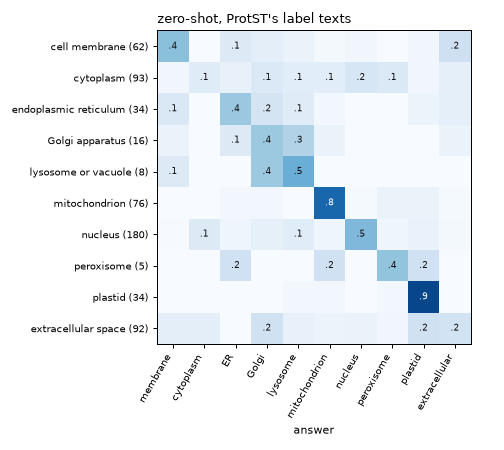

In [ ]:
#| code-fold: true
#| code-summary: confusion matrix
def confusion(recs, answers, qid="location"):
    "Row-normalised confusion matrix over the location compartments"
    m = np.zeros((len(KEYS), len(KEYS)))
    for r, a in zip(recs, answers): m[KEYS.index(r["gold"][qid]), KEYS.index(a[qid]["choice"])] += 1
    return m / np.clip(m.sum(1, keepdims=True), 1, None), m.sum(1)

def plot_confusions(pairs):
    "Confusion matrices side by side, one per (title, recs, answers)"
    fig, axs = plt.subplots(1, len(pairs), figsize=(5.6 * len(pairs), 5), squeeze=False)
    for ax, (title, recs, answers) in zip(axs[0], pairs):
        m, n = confusion(recs, answers)
        ax.imshow(m, cmap="Blues", vmin=0, vmax=1)
        for i in range(len(KEYS)):
            for j in range(len(KEYS)):
                if m[i, j] >= 0.1: ax.text(j, i, f"{m[i, j]:.1f}".lstrip("0"), ha="center", va="center", fontsize=7, color="white" if m[i, j] > 0.5 else INK)
        ax.set_xticks(range(len(KEYS)), [SHORT[k] for k in KEYS], rotation=60, ha="right", fontsize=8)
        ax.set_yticks(range(len(KEYS)), [f"{k} ({int(c)})" for k, c in zip(KEYS, n)], fontsize=8)
        ax.set_xlabel("answer", fontsize=9); ax.set_title(title, fontsize=10, loc="left")
    fig.tight_layout(); show_figure(fig)

best_prompt = zs_table.macro_f1.idxmax()
plot_confusions([(f"zero-shot, {best_prompt}", only(test_recs, "location", criteria=PROMPTS[best_prompt][1]), zs_answers[best_prompt])])

Zero-shot ProtST is good where a protein carries a targeting signal its training texts describe. It places 0.8 of the mitochondrial proteins and 0.9 of the plastid ones, both imported through an N-terminal transit peptide. It is poor on the two commonest compartments after the nucleus. It finds 0.1 of the cytoplasmic proteins, scattering the rest over six other compartments, and 0.2 of the secreted ones, sending as many to the Golgi and to plastids. The nucleus sits in between at 0.5. The ER, the Golgi and the lysosome are confused with each other, which fits: their proteins travel the same secretory route.

### The membrane noul and the shortlist

A noul has two option texts, one per side: `criteria={"false": …, "true": …}`. Three phrasings are tried. The first is two plain descriptions. The second is two Swiss-Prot-style location lines (what ProtST read in training). The third gives the noul no criteria at all, so the statement is compared with its negation, *It is not the case that the protein is bound to a membrane.*:

In [ ]:
NOULS = {"plain descriptions": {"false": "a soluble protein", "true": "a membrane protein"},
         "Swiss-Prot lines": {"false": "SUBCELLULAR LOCATION: Cytoplasm. Secreted.", "true": "SUBCELLULAR LOCATION: Membrane; Multi-pass membrane protein."},
         "the statement and its negation": None}
def noul_records(recs, crit):
    "The records' membrane nouls with these two option texts (None: no criteria, so the statement is weighed against its negation)"
    q = {k: v for k, v in MEMBRANE.items() if k != "criteria"} | ({"criteria": crit} if crit else {})
    return [r | {"questions": {"membrane": q}} for r in only(recs, "membrane")]

noul_scores = {}
for name, crit in NOULS.items():
    zs = zero_shot(protst, proteins=proteins)
    zs.calibrate(noul_records(calib_recs, crit))
    test_m = noul_records(test_recs, crit)
    noul_scores[name] = dict(scores(test_m, answer_all(zs, test_m)).loc["membrane"]) | {"temperature": round(zs.temperatures.get("noul", 1.0), 2)}
membrane_share = np.mean([r["gold"]["membrane"] for r in only(test_recs, "membrane")])
print(f"membrane-bound share of the test nouls: {membrane_share:.3f} (always answering 'soluble' scores {1 - membrane_share:.3f})")
pd.DataFrame(noul_scores).T.astype({"n": int})

membrane-bound share of the test nouls: 0.422 (always answering 'soluble' scores 0.578)


,accuracy,macro_f1,brier,ece,n,temperature
plain descriptions,0.633,0.633,0.459,0.059,360,3.58
Swiss-Prot lines,0.758,0.755,0.312,0.078,360,1.08
the statement and its negation,0.536,0.536,0.507,0.055,360,5.00


The Swiss-Prot lines win again: 0.758 accuracy against 0.578 for always answering *soluble*, with a temperature near 1 (1.08), so their logits were about right as they were. Plain descriptions reach 0.633 and needed their logits flattened (3.58). The statement against its negation is barely better than a coin (0.536), and its temperature hits sysone's upper bound of 5. The text tower hardly tells *The protein is bound to a membrane.* from *It is not the case that the protein is bound to a membrane.*, which is what the [zeroshot](../11_zeroshot.ipynb#two-towers-similarity) notebook warns about for two-tower models.

The shortlist question asks for the right compartment among four, and a third of the time none of the four is right. A zero-shot decider has no way to say so: it always answers. Its only signal is its own confidence, its top probability. The next cell scores the answerable shortlists (with ProtST's label texts), and then shows how that confidence splits the answerable questions from the unanswerable ones:

In [ ]:
zs_short = zero_shot(protst, proteins=proteins)
zs_short.calibrate(only(calib_recs, "shortlist"), act_accuracy=0.9)
test_s = only(test_recs, "shortlist")
zs_short_answers = answer_all(zs_short, test_s)
answerable = np.array([not isinstance(r["gold"]["shortlist"], dict) for r in test_s])
zs_conf = np.array([a["shortlist"]["answer_confidence"] for a in zs_short_answers])
print(scores(test_s, zs_short_answers).to_string())
print(f"mean top probability: {zs_conf[answerable].mean():.3f} when the answer is on the list, {zs_conf[~answerable].mean():.3f} when it isn't")

           accuracy  macro_f1  brier    ece    n
shortlist     0.604     0.493  0.506  0.087  402
mean top probability: 0.572 when the answer is on the list, 0.517 when it isn't


On the answerable shortlists, zero-shot is right 0.604 of the time, against 0.25 for a guess among four. Its confidence barely moves when the right answer is missing, though. Its top probability averages 0.572 when the answer is on the list and 0.517 when it isn't, too close for a threshold to tell the two apart, as [the last part](#acting-or-escalating) confirms.

Six test proteins as prediction cards, each with its hydropathy profile and the zero-shot probabilities of its most likely compartments:

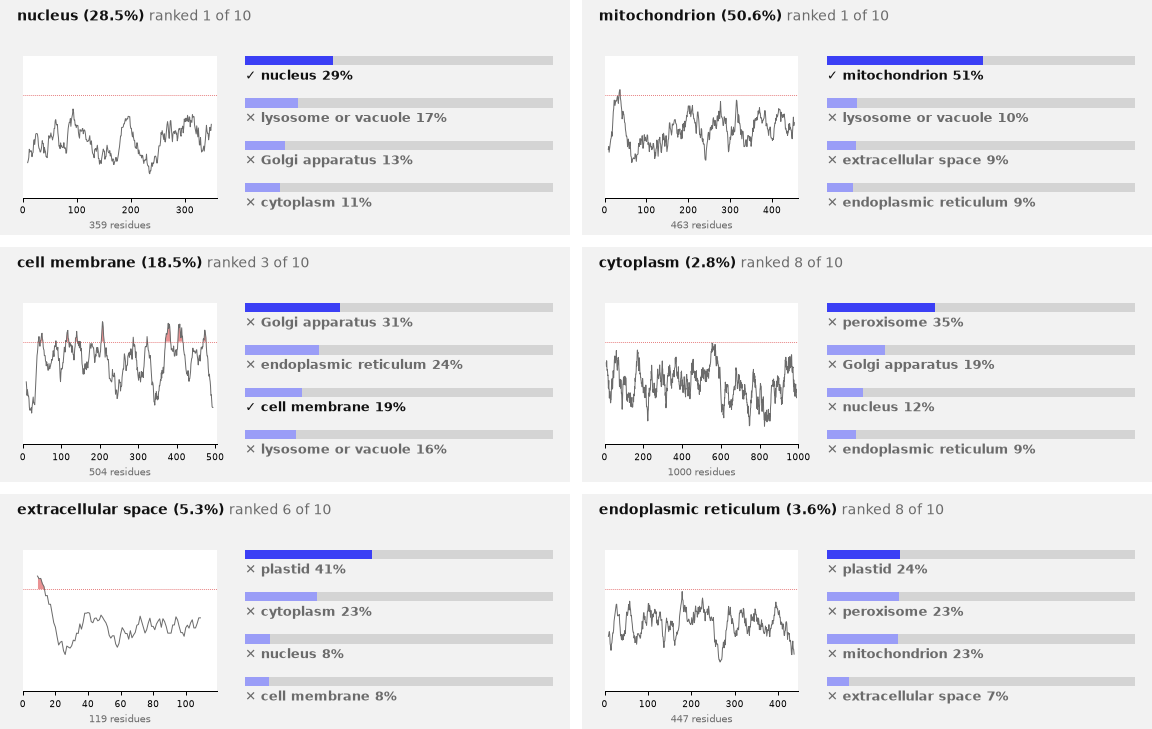

In [ ]:
zs_best = deciders[best_prompt]
def cards_for(model, recs, criteria=None, note=None):
    "A card per record: its sequence, gold compartment and the model's location probabilities"
    out = []
    for r in only(recs, "location", criteria=criteria):
        a = model.predict(r["state"], r["questions"])["location"]
        out.append({"seq": r["state"]["sequence"], "gold": r["gold"]["location"], "probs": a["probabilities"], "note": note(a) if note else ""})
    return out
show_cards(cards_for(zs_best, card_recs, criteria=PROMPTS[best_prompt][1]))

In [ ]:
print("the zero-shot answer to the location question for the first card's protein:")
print(json.dumps(zs_best.predict(card_recs[0]["state"], {"location": LOCATION}), indent=1))

the zero-shot answer to the location question for the first card's protein:
{
 "location": {
  "type": "choice",
  "choice": "nucleus",
  "probabilities": {
   "cell membrane": 0.0464,
   "cytoplasm": 0.1139,
   "endoplasmic reticulum": 0.1,
   "Golgi apparatus": 0.1304,
   "lysosome or vacuole": 0.1707,
   "mitochondrion": 0.0653,
   "nucleus": 0.2854,
   "peroxisome": 0.0667,
   "plastid": 0.0114,
   "extracellular space": 0.0099
  },
  "confidence": 0.1312,
  "answer_confidence": 0.2854,
  "action": {
   "act_probability": 0.2854,
   "act": false
  }
 }
}


Two of the six are right, the nuclear and the mitochondrial protein, and the probabilities are low throughout. The top option passes 50% only once, which suits a model that is right about four times in ten. The secreted protein shows the failure from the confusion matrix: its N-terminal signal peptide is the textbook mark of secretion, yet the answer is *plastid* at 41%. The JSON is the answer as a caller gets it. The decider was calibrated with `act_accuracy=0.9`, so it also says whether to act (`action`). At 28% it doesn't.

## Training a head

The protein application, `sysone.protein.decision_learner`, keeps both towers frozen. PubMedBERT reads a text row per question (the question, and an anchor before each option), and ESM reads the protein as a side stream. A pair head scores each option's anchor against the protein's vector. `act=True` adds Laya's act head. It reads the row's first position, the protein's vector, and four numbers about the option probabilities, and it learns whether answering would be right. That covers questions whose right answer isn't an option, like the unanswerable shortlists.

The towers are frozen, so the learner encodes every row once and caches the vectors (float32, on disk). Each protein goes through ESM once, however many questions ask about it. This is the slow step of the notebook. After it, training runs on the cached vectors in seconds. The learner reuses the loaded ProtST, so no second copy is made.

A text row, as PubMedBERT reads it:

In [ ]:
data = TypedDecisions(train_recs, valid_recs, calib_recs)
torch.manual_seed(0)
learn = quiet(decision_learner(data, protst, act=True, preset="macbook", loss="soft_ce", cache_dir=work / "cache",
                               calibrate_after_fit=False, per_device_train_batch_size=32))
print(show_row(data.builder.build_record(train_recs[0])[-1], data.builder.tok, max_chars=500))
print(learn)          # printed, not displayed: IPython's output cache would keep the learner, and ProtST, alive

[CLS] choice question : which of these compartments is the protein found in? [SEP] [MASK] endoplasmic reticulum : subcellular location : endoplasmic reticulum ( er ). [MASK] golgi apparatus : subcellular location : golgi apparatus. [MASK] plastid : subcellular location : plastid. [MASK] extracellular space : subcellular location : extracellular. [SEP]×2
markers [15, 28, 38, 46] · qtype choice · 57 tokens · protein 275 tokens
Learner(MilaDeepGraph/ProtST-ESM1b · regime head · head 0 layers/pair · cache masks · loss soft_ce · 858,627 of 762,762,648 params train)


In [ ]:
t0 = time.time()
for split in ("train", "valid", "calib"): learn.dataset(split)
n_rows = sum(len(learn.dataset(s)) for s in ("train", "valid", "calib"))
print(f"{n_rows} rows of {len(train_recs) + len(valid_recs) + len(calib_recs)} proteins encoded in {time.time() - t0:.0f} s · {memory()}")

4573 rows of 1750 proteins encoded in 410 s · peak RSS 4.8 GB · MPS driver 3.0 GB


The head trains for 4 epochs on the cached vectors, with a learning rate warmed up and then annealed. A first run trained for 12: its validation loss was lowest after the third epoch and then rose, while the training loss went to zero. `calibrate` then fits the temperatures on the calibration proteins, and the act thresholds, one per question type and option count: the lowest act probability at which the answers acted on there are still 90% right.

In [ ]:
t0 = time.time()
learn.fit_one_cycle(4, lr=1e-3)
learn.calibrate(act_accuracy=0.9)
head_rule = dict(learn.act_threshold)
print(f"trained and calibrated in {time.time() - t0:.0f} s · temperatures {learn.temperatures}")
print("act-head thresholds:", {k: round(v, 3) for k, v in head_rule.items()})

trained and calibrated in 11 s · temperatures {'choice': 1.5685, 'choice:3-5': 1.6028, 'choice:6-10': 1.5578, 'noul': 1.4716, 'noul:2': 1.4716}
act-head thresholds: {'all': 0.932, 'choice': 0.93, 'noul': 0.942, 'choice:3-5': 0.879, 'choice:6-10': 0.93, 'noul:2': 0.942}


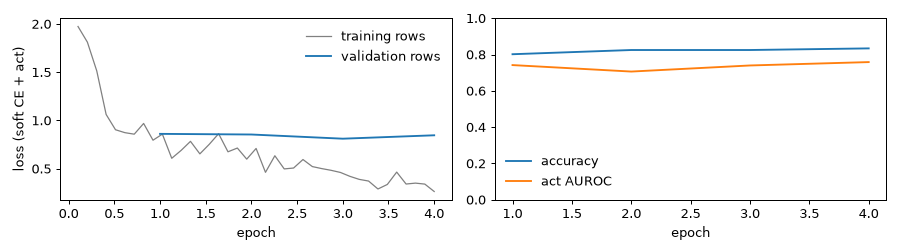

In [ ]:
#| code-fold: true
#| code-summary: training curves
ms, tr = learn.recorder.metrics, learn.recorder.losses
ep = [m["epoch"] for m in ms]; x = np.linspace(ep[-1] / len(tr), ep[-1], len(tr))
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 2.8))
a.plot(x, tr, color="gray", lw=1, label="training rows"); a.plot(ep, [m["loss"] for m in ms], color="C0", lw=1.5, label="validation rows")
a.set(xlabel="epoch", ylabel="loss (soft CE + act)"); a.legend(frameon=False)
b.plot(ep, [m["accuracy"] for m in ms], color="C0", lw=1.5, label="accuracy"); b.plot(ep, [m["act_auroc"] for m in ms], color="C1", lw=1.5, label="act AUROC")
b.set(xlabel="epoch", ylim=(0, 1)); b.legend(frameon=False)
fig.tight_layout(); show_figure(fig)

The validation loss stays flat around 0.85 while the training loss keeps falling, and validation accuracy climbs from 0.80 to 0.83. The act head's AUROC stays near 0.75 throughout, meaning it separates the answers worth acting on from the rest, but not by much. The first, 12-epoch run showed where more training leads: the validation loss rose from its low at epoch 3 to 1.5, the fitted temperatures grew to about 3 to undo the head's overconfidence, and its accuracy on the test proteins' location question was 0.790, against this run's 0.828.

## Zero-shot or a head?

The learner's `decider()` answers the test records the way its export would, with the act head's verdict in each answer (`action`). The zero-shot rows use the best prompt for the location question, ProtST's label texts for the shortlist, and the best phrasing for the noul:

In [ ]:
jev = learn.decider()                    # the act head's rule, as calibrated
t0 = time.time()
head_answers = answer_all(jev, test_recs)
print(f"{len(test_recs)} proteins answered in {time.time() - t0:.0f} s · {memory()}")
print(json.dumps(head_answers[0], indent=1)[:1200])

600 proteins answered in 162 s · peak RSS 4.8 GB · MPS driver 3.1 GB
{
 "location": {
  "type": "choice",
  "choice": "nucleus",
  "probabilities": {
   "cell membrane": 0.0003,
   "cytoplasm": 0.0405,
   "endoplasmic reticulum": 0.0009,
   "Golgi apparatus": 0.0009,
   "lysosome or vacuole": 0.0001,
   "mitochondrion": 0.0035,
   "nucleus": 0.9509,
   "peroxisome": 0.0024,
   "plastid": 0.0004,
   "extracellular space": 0.0002
  },
  "confidence": 0.899,
  "answer_confidence": 0.9509,
  "action": {
   "act_probability": 0.9742,
   "act": true
  }
 },
 "shortlist": {
  "type": "choice",
  "choice": "endoplasmic reticulum",
  "probabilities": {
   "cell membrane": 0.2416,
   "endoplasmic reticulum": 0.2827,
   "Golgi apparatus": 0.2189,
   "plastid": 0.2568
  },
  "confidence": 0.0031,
  "answer_confidence": 0.2827,
  "action": {
   "act_probability": 0.7393,
   "act": false
  }
 }
}


In [ ]:
best_noul = max(noul_scores, key=lambda k: noul_scores[k]["accuracy"])
zs_noul = zero_shot(protst, proteins=proteins)
zs_noul.calibrate(noul_records(calib_recs, NOULS[best_noul]), act_accuracy=0.9)
test_m = noul_records(test_recs, NOULS[best_noul])
zs_noul_answers = answer_all(zs_noul, test_m)
zs_rows = {"location": scores(only(test_recs, "location", criteria=PROMPTS[best_prompt][1]), zs_answers[best_prompt]).loc["location"],
           "membrane": scores(test_m, zs_noul_answers).loc["membrane"],
           "shortlist": scores(test_s, zs_short_answers).loc["shortlist"]}
head_rows = scores(test_recs, head_answers)
comparison = pd.concat({"zero-shot": pd.DataFrame(zs_rows).T, "head": head_rows}, axis=1).swaplevel(0, 1, axis=1)
comparison[[(m, w) for m in ("accuracy", "macro_f1", "brier", "ece") for w in ("zero-shot", "head")]]

accuracy         macro_f1            brier              ece       
          zero-shot   head zero-shot   head zero-shot   head zero-shot   head
location      0.418  0.828     0.348  0.631     0.716  0.267     0.067  0.033
membrane      0.758  0.906     0.755  0.904     0.312  0.140     0.078  0.031
shortlist     0.604  0.896     0.493  0.726     0.506  0.164     0.087  0.029

The head roughly doubles zero-shot's accuracy on the location question (0.828 against 0.418), and nearly doubles its macro-F1 (0.631 against 0.348). It gains less on the membrane noul (0.906 against 0.758) and on the shortlist (0.896 against 0.604). Its probabilities are better calibrated too, with an ECE of about 0.03 on every question. That's what 1,200 labelled proteins buy with the towers frozen, in 11 seconds of training and calibration on cached vectors. On the location question the head's macro-F1 trails its accuracy by 0.2, a sign that it is weaker on the rare compartments. The next plot shows it.

Recall per compartment, the share of each compartment's proteins answered right, for the best zero-shot prompt and the head:

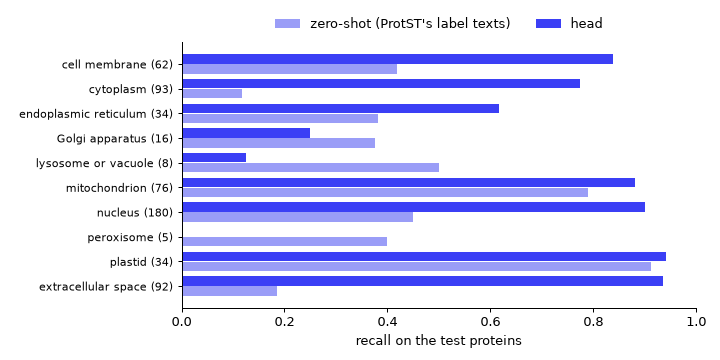

In [ ]:
#| code-fold: true
#| code-summary: recall per compartment
def recall(recs, answers):
    ok = pd.DataFrame({"gold": [r["gold"]["location"] for r in recs], "ok": [a["location"]["choice"] == r["gold"]["location"] for r, a in zip(recs, answers)]})
    return ok.groupby("gold").ok.mean().reindex(KEYS)

rz, rh = recall(test_recs, zs_answers[best_prompt]), recall(test_recs, head_answers)
counts = pd.Series([r["gold"]["location"] for r in test_recs]).value_counts().reindex(KEYS)
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(KEYS))
ax.barh(y + 0.2, rz, 0.38, color=LIGHT, label=f"zero-shot ({best_prompt})"); ax.barh(y - 0.2, rh, 0.38, color=BLUE, label="head")
ax.set_yticks(y, [f"{k} ({c})" for k, c in zip(KEYS, counts)], fontsize=9); ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_xlabel("recall on the test proteins"); ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.tight_layout(); show_figure(fig)

The head's gains come from the common compartments. It finds 0.78 of the cytoplasmic proteins where zero-shot found 0.12, 0.94 of the secreted ones (zero-shot: 0.18) and 0.90 of the nuclear ones (zero-shot: 0.45). On the three rarest it does worse than zero-shot. It misses all five peroxisomal proteins (zero-shot found two), finds one lysosomal protein in eight (zero-shot: four) and four Golgi proteins in sixteen (zero-shot: six). With 17 to 27 training examples each, those compartments are too thin for a head trained from scratch, while zero-shot needs no examples at all. More examples of the rare compartments, or a loss that weighs them up, would be the next thing to try.

The same six proteins, now answered by the head. The note gives the act head's verdict:

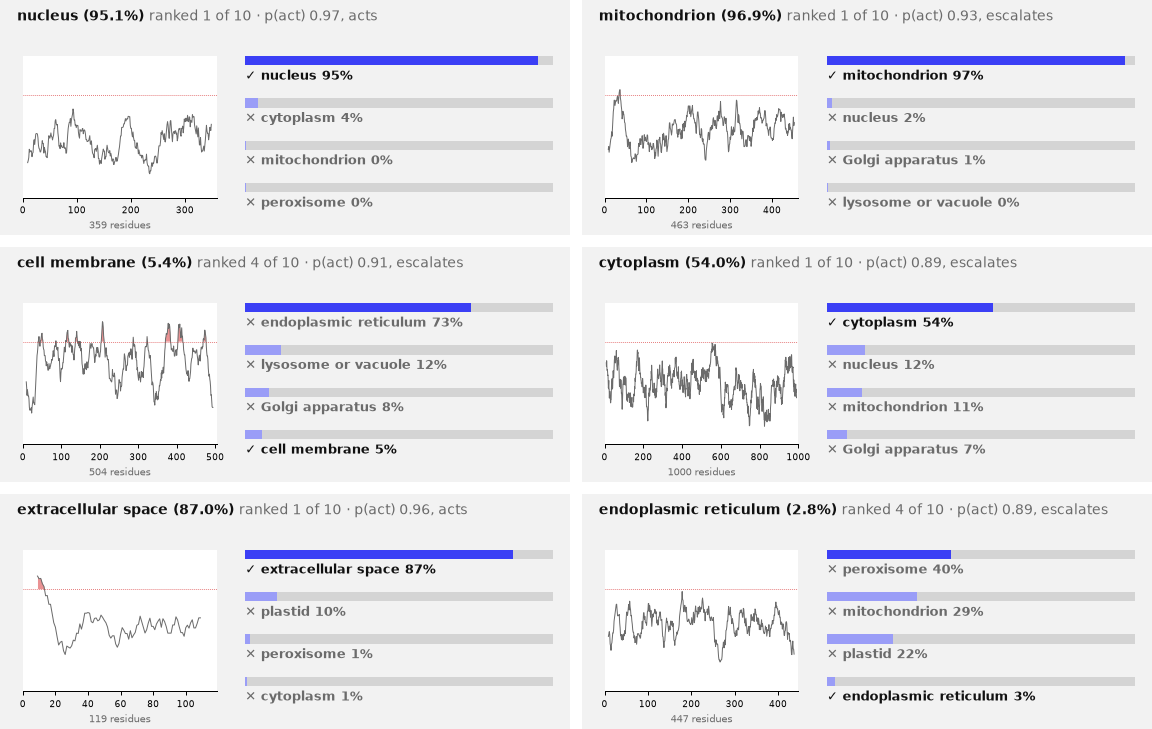

In [ ]:
verdict = lambda a: f"· p(act) {a['action']['act_probability']:.2f}, {'acts' if a['action']['act'] else 'escalates'}"
show_cards(cards_for(jev, card_recs, note=verdict))

Four of the six are right now, three of them above 85%. The two wrong ones are the proteins zero-shot also missed, the cell-membrane and the ER protein, and the act head escalates both. It also escalates the mitochondrial protein, answered right at 97%, because its p(act) of 0.93 sits just under the threshold for choices of six to ten options (0.930). p(act) runs high for nearly every answer, so its threshold has little room to work in.

## Acting or escalating

A decision model should say when it doesn't know. Laya's rule is its act head's p(act) against a threshold, and the act head is trained on whether answering would have been right. A simpler rule thresholds the model's own calibrated top probability, and it works for any model, a zero-shot one included. sysone fits either kind of threshold on the calibration proteins, one per question type and option count, for a target accuracy on the answers acted on (90% here). `calibrate(act_score="confidence")` switches the learner to the second rule, and every zero-shot decider above already fitted its own thresholds with `act_accuracy=0.9`.

Each rule is judged by what it lets through. Sort the test questions by the score and act on the top share. The curve plots the accuracy of the answers acted on against that share (the coverage), and a good score keeps the accuracy high while the coverage grows. An unanswerable shortlist counts as wrong whenever it is acted on. The dots mark where each rule's fitted thresholds land:

confidence thresholds: {'all': 0.852, 'choice': 0.907, 'noul': 0.547, 'choice:3-5': 0.974, 'choice:6-10': 0.73, 'noul:2': 0.547}


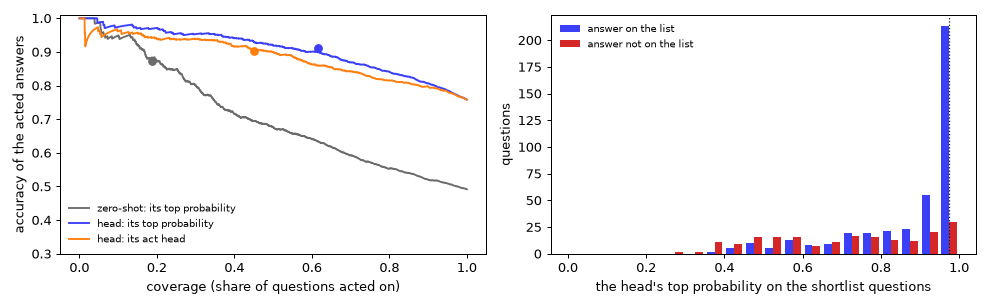

acts on  right when it acts  acts on the unanswerable
location  zero-shot, top probability    0.030               0.944                       NaN
          head, top probability         0.703               0.915                       NaN
          head, act head                0.572               0.910                       NaN
shortlist zero-shot, top probability    0.043               1.000                     0.000
          head, top probability         0.310               0.892                     0.091
          head, act head                0.028               0.647                     0.030
membrane  zero-shot, top probability    0.694               0.856                       NaN
          head, top probability         0.981               0.915                       NaN
          head, act head                0.958               0.910                       NaN

In [ ]:
learn.calibrate(act_accuracy=0.9, act_score="confidence")
conf_rule = dict(learn.act_threshold)
print("confidence thresholds:", {k: round(v, 3) for k, v in conf_rule.items()})

def is_right(q, ans, gold) -> bool:
    "Whether acting on an answer is right: the gold is among the options and the answer is the gold"
    if q.answerable(gold) != 1: return False
    return (ans["noul"] >= 0.5) == bool(gold) if q.type == "noul" else ans["choice"] == gold

def question_rows(recs, answers, zero_shot_answers):
    "One row per test question: whether acting is right, and each rule's score and verdict (zero-shot confidence, head confidence, act head)"
    zs = {(r["id"], qid): a[qid] for rs, ans in zero_shot_answers for r, a in zip(rs, ans) for qid in a}
    out = []
    for r, a in zip(recs, answers):
        for qid, ans in a.items():
            q, g, z = Question.from_dict(r["questions"][qid], name=qid), r["gold"][qid], zs[(r["id"], qid)]
            out.append({"qid": qid, "answerable": q.answerable(g) == 1, "right": is_right(q, ans, g), "zs_right": is_right(q, z, g),
                        "p_act": ans["action"]["act_probability"], "acts": ans["action"]["act"],
                        "head_conf": ans["answer_confidence"], "conf_acts": ans["answer_confidence"] >= lookup_threshold(conf_rule, q.qtype, q.k),
                        "zs_conf": z["answer_confidence"], "zs_acts": z["action"]["act"]})
    return pd.DataFrame(out)

acts = question_rows(test_recs, head_answers, [(only(test_recs, "location"), zs_answers[best_prompt]), (test_m, zs_noul_answers),
                                               (test_s, zs_short_answers)])
RULES = {"zero-shot: its top probability": ("zs_conf", "zs_acts", "zs_right", GRAY),
         "head: its top probability": ("head_conf", "conf_acts", "right", BLUE),
         "head: its act head": ("p_act", "acts", "right", "C1")}
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
for label, (score, verdict, right, color) in RULES.items():
    cv = coverage_curve(acts[score].values, acts[right].values.astype(float))
    axs[0].plot(cv["coverage"], cv["accuracy"], color=color, lw=1.5, label=label)
    axs[0].plot([acts[verdict].mean()], [acts[right][acts[verdict]].mean()], "o", color=color, ms=6)
axs[0].set(xlabel="coverage (share of questions acted on)", ylabel="accuracy of the acted answers", ylim=(0.3, 1.01)); axs[0].legend(frameon=False, fontsize=8)
sh = acts[acts.qid == "shortlist"]
axs[1].hist([sh.head_conf[sh.answerable], sh.head_conf[~sh.answerable]], bins=20, range=(0, 1), color=[BLUE, RED], label=["answer on the list", "answer not on the list"])
axs[1].axvline(lookup_threshold(conf_rule, "choice", 4), color=INK, ls=":", lw=1)
axs[1].set(xlabel="the head's top probability on the shortlist questions", ylabel="questions"); axs[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); show_figure(fig)

def rule_table(df):
    "Per question and rule: the share acted on, the accuracy when acting, and the share of unanswerable questions acted on"
    out = {}
    for qid, d in df.groupby("qid", sort=False):
        for label, (_, verdict, right, _) in RULES.items():
            a = d[verdict].astype(bool)
            out[(qid, label.split(":")[0] + ", " + label.split(": ")[1].replace("its ", ""))] = {
                "acts on": round(a.mean(), 3), "right when it acts": round(d[right][a].mean(), 3) if a.any() else np.nan,
                "acts on the unanswerable": round(a[~d.answerable].mean(), 3) if (~d.answerable).any() else np.nan}
    return pd.DataFrame(out).T

rule_table(acts)

The head's own top probability is the better escalation score on every question. At the 90% target it acts on 70% of the location questions (0.915 of them right), where the act head acts on 57% (0.910). It acts on 31% of the shortlists (0.892 right), where the act head acts on 3%, and gets only 0.647 of those right, well below the target. In the left plot its curve lies above the act head's almost everywhere. The histogram shows why the shortlists are hard. When the right compartment is on the list, the head usually gives it a top probability near 1. The unanswerable shortlists spread out lower, but a tail of them still reaches 0.97. At the fitted threshold (0.974) the head acts on 9% of the unanswerable shortlists, so about one question in eleven that has no right answer still gets one. Zero-shot rarely acts: its confidence seldom reaches its thresholds, so it acts on 3% of the location questions and 4% of the shortlists, though on 69% of the nouls.

Laya's act head learns from the rows the option head trains on. On those rows the option head is right far more often than on new proteins, so the act head learns that acting is nearly always right, and its p(act) crowds near 1. Fitting the act head on the calibration rows instead did not fix it: in a separate test on the same cached vectors, its AUROC on the validation split was 0.71 to 0.74, against the top probability's 0.81. So the export below uses `act_score="confidence"`. The act head is still there for tasks where it earns its place, and `calibrate` fits either rule per question type and option count.

## The export

`learn.export` writes the head, the two tokenizers and the calibration, which now holds the confidence rule and its thresholds. ProtST's towers didn't train, so the export refers to the Hub checkpoint by id and by its source, `protst`, instead of copying 3 GB. The ProtST copy in memory is released first, since `Decider.load` loads the checkpoint again, through the same tensors-only path:

In [ ]:
out = learn.export(work / "protein-jev")
size = sum(f.stat().st_size for f in out.rglob("*") if f.is_file())
print(f"{out}: {size / 1e6:.1f} MB · encoder {json.loads((out / 'sysone.json').read_text())['encoder']}")
probe = test_recs[5]
before = learn.predict(probe["state"], probe["questions"])          # with the rule the export carries
del jev, learn, deciders, zs, zs_best, zs_noul, zs_short, proteins, protst
print(memory())

protein-decisions/protein-jev: 4.1 MB · encoder {'id': 'MilaDeepGraph/ProtST-ESM1b', 'revision': None, 'source': 'protst', 'hidden_size': 768, 'family': 'protst', 'modality': 'text', 'dtype': 'float32', 'weights': 'hub'}
peak RSS 4.8 GB · MPS driver 0.0 GB


In [ ]:
t0 = time.time()
loaded = Decider.load(out, device=device)
after = loaded.predict(probe["state"], probe["questions"])
print(f"loaded in {time.time() - t0:.0f} s · same answers: {after == before}")
print(json.dumps({"state": {"sequence": probe["state"]["sequence"][:40] + "…"}, "questions": list(probe["questions"]),
                  "gold": probe["gold"], "answers": after}, indent=1)[:2000])

loaded in 3 s · same answers: True
{
 "state": {
  "sequence": "MPLLQPSTCFCYPLKLPPLPLTSDSNEFDECARKRLTLDY\u2026"
 },
 "questions": [
  "location",
  "membrane",
  "shortlist"
 ],
 "gold": {
  "location": "cytoplasm",
  "membrane": false,
  "shortlist": "cytoplasm"
 },
 "answers": {
  "location": {
   "type": "choice",
   "choice": "cytoplasm",
   "probabilities": {
    "cell membrane": 0.0203,
    "cytoplasm": 0.5405,
    "endoplasmic reticulum": 0.0653,
    "Golgi apparatus": 0.066,
    "lysosome or vacuole": 0.0399,
    "mitochondrion": 0.1147,
    "nucleus": 0.1229,
    "peroxisome": 0.0275,
    "plastid": 0.0022,
    "extracellular space": 0.0008
   },
   "confidence": 0.3391,
   "answer_confidence": 0.5405,
   "action": {
    "act_probability": 0.5405,
    "act": false
   }
  },
  "membrane": {
   "type": "noul",
   "noul": 0.3594,
   "confidence": 0.6406,
   "answer_confidence": 0.6406,
   "action": {
    "act_probability": 0.6406,
    "act": true
   }
  },
  "shortlist": {
   "ty

The export is 4.1 MB: the head's weights, the two tokenizers and `sysone.json`, which names the encoder by its Hub id and its `protst` source. `Decider.load` rebuilt ProtST from the Hub checkpoint through the same tensors-only loader, in 3 seconds from the cache, and gives the same answers as the learner. Its `action` now follows the confidence rule. `act_probability` is the answer's calibrated top probability, and `act` compares it with the threshold for its question type and option count. This protein is cytoplasmic and the head says so, but at 54%, below the 10-way threshold of 0.73, so it escalates. It acts on the membrane noul, whose threshold is 0.547, and answers *soluble* at 64%, which is right. It also names the right compartment on the shortlist, at 83%, but escalates it, since shortlists need 0.974.

## What this shows

- **Zero-shot works, and the wording decides how well.** With ProtST's own label texts, zero-shot ProtST answers the 10-way location question 0.418 of the time, against 0.300 for always answering *nucleus*, and other wordings stay near that baseline. The membrane noul is the same story: 0.758 with Swiss-Prot-style lines, against 0.578 for always answering *soluble*, and 0.536 for the statement against its negation. Zero-shot is strongest where a protein's targeting signal is well described in text (mitochondria and plastids) and weakest on cytoplasmic and secreted proteins.
- **A head on the frozen towers is worth training.** Trained on 1,200 proteins in seconds, from vectors cached once, it reaches 0.828 on location, 0.906 on the noul and 0.896 on the shortlists, with an ECE near 0.03. It loses to zero-shot only on the three rarest compartments, which have 17 to 27 training examples each.
- **For escalation, the simple rule won.** Thresholds on the head's calibrated top probability, fitted per question type and option count on the calibration proteins, act on more questions at the 90% target than Laya's act head: 70% against 57% of the location questions, 31% against 3% of the shortlists. Neither rule catches every unanswerable shortlist, and the confidence rule acts on 9% of them. In the first run of this notebook, a single threshold for all questions, which is how sysone fitted it until then, acted on none of the shortlists.
- **It fits a laptop.** One float32 copy of ProtST (3 GB) serves every step: the zero-shot embedders, the learner's stream encoder and its `Decider`. Proteins go through ESM once per step, in batches of 8 sorted by length, and the whole run takes 13 minutes on an M3 Pro.

This notebook doesn't train ProtST's towers. LoRA on the text tower (`train="lora"`) and cross-attention from the text to the protein's residues ([Design B](../03_models.ipynb#cross-attention-from-a-side-stream)) are both available in sysone, but both need gradients through the towers and more memory than a head on cached vectors.

In [ ]:
print(f"total run time {(time.time() - t_start) / 60:.1f} min · {memory()}")

total run time 13.3 min · peak RSS 5.2 GB · MPS driver 3.1 GB
